In [14]:
config_file = "./04_inputs_model_building/01_Config_file/config_file.json"

# Model building

This notebook is expected to be executed to build models on the preprocessed Glassdoor dataset (output from Data preprocessing notebook).

## 1. Import libraries and functions, and initialize code

In [ ]:
!pip install pandas numpy scikit-learn xgboost lightgbm matplotlib openpyxl

In [ ]:
## Import libraries

# Pandas
import pandas as pd

# Itertools
from itertools import product

# Warnings
import warnings

# Pickle
import pickle

# Datetime
from datetime import datetime

# Json
import json

# Plots
import matplotlib.pyplot as plt

# OS
import os

# Platform (for cross-platform sound notification)
import platform

# Sklearn
from sklearn.model_selection import RandomizedSearchCV

from sklearn.decomposition import PCA

from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn import metrics

# XG Boost
import xgboost as xgb

# LightGBM
import lightgbm as lgb


## Configure libraries

# Pandas rows
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

# Warnings
warnings.filterwarnings('ignore')

In [17]:
# Get current datetime
current_datetime = datetime.now().strftime("%Y%m%d_%H%M%S")

# Create empty directory
directory_name = "05_outputs_modeling/output_modeling_" + current_datetime
os.mkdir(directory_name)

In [18]:
# Dictionary to be saved as a pickle object
dict_out = {}

# String to be saved as model summary
str_out = "\n" + current_datetime

## 2. Read data

### 2.1. Actually read data

In [19]:
# Read the config file
with open(config_file, 'r') as file:
    config = json.load(file)

In [20]:
# Read files
folder_to_read = "./03_outputs_data_preprocessing/output_data_preprocessing_" + config['general']['execution to use']
files_to_read = config['general']['execution to use'] + ".csv"

reviews_train_raw = pd.read_csv(folder_to_read + "/dataframes_Train_" + files_to_read)
reviews_test_raw = pd.read_csv(folder_to_read + "/dataframes_Test_" + files_to_read)

### 2.2. Filter features

In [21]:
def check_mean_std(dataframe):
    """
    Function to check if all columns in a Pandas DataFrame have mean between -0.05 and +0.05,
    and standard deviation between 0.95 and 1.05.

    Parameters:
        dataframe (pandas.DataFrame): Input DataFrame

    Returns:
        bool: True if conditions are satisfied for all columns, False otherwise.
    """
    conditions_met = all(((-0.05 <= col_mean <= 0.05) and (0.95 <= col_std <= 1.05))
                        for col_mean, col_std in zip(dataframe.mean(), dataframe.std()))
    return conditions_met

In [22]:
# Get features
input_features = config['features']['input']
output_feature = config['features']['output']
all_features = input_features + [output_feature]

# Filter dataframes
reviews_train = reviews_train_raw[all_features]
reviews_test = reviews_test_raw[all_features]

In [23]:
# Check all variables are numerical
numerical_columns_train = reviews_train.select_dtypes(include=[int, float]).columns
numerical_columns_test = reviews_test.select_dtypes(include=[int, float]).columns

if (len(numerical_columns_train) == len(reviews_train.columns)) and (len(numerical_columns_test) == len(reviews_test.columns)):
    print("All columns numerical")
else:
    raise Exception("Not all columns numerical")

All columns numerical


# Check no missing values
if reviews_train.isna().sum().sum() + reviews_test.isna().sum().sum() == 0:
    print("No missing values")
else:
    raise Exception("Missing values")

# Check mean and standard deviation (only on train)
if check_mean_std(reviews_train.loc[:, input_features]):
    print("Mean 0 and std dev 1 in train")
else:
    raise Exception("Mean not 0 or std dev not 1 in train")

### 2.3. Separate input and output features

In [24]:
# Separate into input and outputs
train_x = reviews_train.drop(output_feature, axis=1).fillna(0)
train_y = reviews_train[output_feature]

test_x = reviews_test.drop(output_feature, axis=1).fillna(0)
test_y = reviews_test[output_feature]

## 3. PCA

In [25]:
def apply_pca(df_train, df_test, str_name, n_comp, random_seed):

    # Initiate PCA object
    pca = PCA(n_components=n_comp)

    # Fit and transform dataframes
    df_train_pca = pd.DataFrame(pca.fit_transform(df_train))
    df_test_pca = pd.DataFrame(pca.transform(df_test))

    # Rename columns with str_name
    df_train_pca = df_train_pca.rename(columns={col: str_name + "_" + str(col) for col in df_train_pca.columns})
    df_test_pca = df_test_pca.rename(columns={col: str_name + "_" + str(col) for col in df_test_pca.columns})

    # Return df and pca object
    return [pca, df_train_pca, df_test_pca]

In [26]:
# Iterate through pca instances to create
for i in range(config['pca']['number of pca']):

    # Get PCA name in config
    pca_name = "pca" + str(i)

    # Print PCA calculation
    print("Applying PCA: " + pca_name)

    # Filter columns
    df_pca_train = train_x[config['pca'][pca_name]['features']]
    df_pca_test = test_x[config['pca'][pca_name]['features']]

    # Apply PCA
    pca_out = apply_pca(df_pca_train, df_pca_test, pca_name, config['pca'][pca_name]['number dimensions'], config['general']['random seed'])

    # Add columns to dataframe and save output correctly
    train_x = pd.concat([train_x, pca_out[1]], axis=1)
    test_x = pd.concat([test_x, pca_out[2]], axis=1)

    dict_out[pca_name] = pca_out[0]

    # Drop original features if requested
    if config['pca'][pca_name]['drop original features'] == "yes":

        # Drop features
        train_x = train_x.drop(columns=config['pca'][pca_name]['features'])
        test_x = test_x.drop(columns=config['pca'][pca_name]['features'])

Applying PCA: pca0
Applying PCA: pca1
Applying PCA: pca2
Applying PCA: pca3
Applying PCA: pca4
Applying PCA: pca5
Applying PCA: pca6
Applying PCA: pca7
Applying PCA: pca8
Applying PCA: pca9
Applying PCA: pca10
Applying PCA: pca11
Applying PCA: pca12


## 4. Train model

### 4.0. Hyperparameter division

In [27]:
def strings_to_floats_or_strings(string_list):
    def convert_if_float(s):
        try:
            if "." in s:
                return float(s)
            else:
                return int(s)
        except ValueError:
            return s

    return [tuple(convert_if_float(part) for part in s.split('_')) for s in string_list]

In [28]:
## Modify config with largest hyperparameter
if type(config['model']['split largest hyperparameter']) == list:  # Multiple variables are used

    # Get all hyperparameter list
    lst_hyperparams = [config['model']['parameters'][hyperparam] for hyperparam in config['model']['split largest hyperparameter']]
    lst_all_executions = list(product(*lst_hyperparams))

    # Get already executed hyperparams
    try:
        lst_previous_executions = strings_to_floats_or_strings(os.listdir("05_outputs_modeling/" + config['model']['complete execution output']))
    except KeyError:
        lst_previous_executions = []

    # Get next executions
    lst_upcoming_executions = [element for element in lst_all_executions if element not in lst_previous_executions]

    # Modify config file
    for i, hyperparam in enumerate(config['model']['split largest hyperparameter']):
        config['model']['parameters'][hyperparam] = [lst_upcoming_executions[0][i]]

    # Modify search number of iterations
    config['search']['number search iterations'] = int(config['search']['number search iterations'] / len(lst_all_executions))

    # Modify output directory
    directory_name = "05_outputs_modeling/" + config['model'].get('complete execution output', 'default_execution') + "/" + '_'.join(str(element) for element in lst_upcoming_executions[0])
    os.makedirs(directory_name, exist_ok=True)
    

### 4.1. Linear regression / Elastic net

In [29]:
## Train elastic net (linear regression)
if config['model']['model type'] == "elasticnet":

    # Get start time of model
    starttime = datetime.now()

    # Get parameters to train
    params_grid = config['model']['parameters']

    # State model
    model = ElasticNet(random_state=config['general']['random seed'])

    # State random search
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params_grid,
        n_iter=config['search']['number search iterations'],
        scoring=config['search']['cv evaluation'],
        cv=config['search']['number folds'],
        random_state=config['general']['random seed'],
        n_jobs=config['search']['n_jobs'],
        verbose=1)

    # Train model
    random_search.fit(train_x, train_y)

    # Print end time
    endtime = datetime.now()
    print("Time to train model: " + str(endtime - starttime))

    # Save training and cross-validation restults
    pd.DataFrame(random_search.cv_results_).to_csv(directory_name + "/Building summary_" + current_datetime + ".csv")

    # Save random search object
    dict_out['Random search object'] = random_search

### 4.2. KNN

In [30]:
## Train knn
if config['model']['model type'] == "knn":

    # Get start time of model
    starttime = datetime.now()

    # Get parameters to train
    params_grid = config['model']['parameters']

    # State model
    model = KNeighborsRegressor()

    # State random search
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params_grid,
        n_iter=config['search']['number search iterations'],
        scoring=config['search']['cv evaluation'],
        cv=config['search']['number folds'],
        random_state=config['general']['random seed'],
        n_jobs=config['search']['n_jobs'],
        verbose=1)

    # Train model
    random_search.fit(train_x, train_y)

    # Print end time
    endtime = datetime.now()
    print("Time to train model: " + str(endtime - starttime))

    # Save training and cross-validation restults
    pd.DataFrame(random_search.cv_results_).to_csv(directory_name + "/Building summary_" + current_datetime + ".csv")

    # Save random search object
    dict_out['Random search object'] = random_search

Fitting 5 folds for each of 40 candidates, totalling 200 fits


KeyboardInterrupt: 

### 4.3. Decision tree

In [ ]:
## Train decision tree
if config['model']['model type'] == "decision tree":

    # Get start time of model
    starttime = datetime.now()

    # Get parameters to train
    params_grid = config['model']['parameters']

    # State model
    model = DecisionTreeRegressor(random_state=config['general']['random seed'])

    # State random search
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params_grid,
        n_iter=config['search']['number search iterations'],
        scoring=config['search']['cv evaluation'],
        cv=config['search']['number folds'],
        random_state=config['general']['random seed'],
        n_jobs=config['search']['n_jobs'],
        verbose=1)

    # Train model
    random_search.fit(train_x, train_y)

    # Print end time
    endtime = datetime.now()
    print("Time to train model: " + str(endtime - starttime))

    # Save training and cross-validation restults
    pd.DataFrame(random_search.cv_results_).to_csv(directory_name + "/Building summary_" + current_datetime + ".csv")

    # Save random search object
    dict_out['Random search object'] = random_search

### 4.4. Random forest

In [ ]:
## Train random forest
if config['model']['model type'] == "random forest":

    # Get start time of model
    starttime = datetime.now()

    # Get parameters to train
    params_grid = config['model']['parameters']

    # State model
    model = RandomForestRegressor(random_state=config['general']['random seed'])

    # State random search
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params_grid,
        n_iter=config['search']['number search iterations'],
        scoring=config['search']['cv evaluation'],
        cv=config['search']['number folds'],
        random_state=config['general']['random seed'],
        n_jobs=config['search']['n_jobs'],
        verbose=1)

    # Train model
    random_search.fit(train_x, train_y)

    # Print end time
    endtime = datetime.now()
    print("Time to train model: " + str(endtime - starttime))

    # Save training and cross-validation restults
    pd.DataFrame(random_search.cv_results_).to_csv(directory_name + "/Building summary_" + current_datetime + ".csv")

    # Save random search object
    dict_out['Random search object'] = random_search

### 4.5. Support vector machine

In [ ]:
## Train support vectur machine
if config['model']['model type'] == "support vector machine":

    # Get start time of model
    starttime = datetime.now()

    # Get parameters to train
    params_grid = config['model']['parameters']

    # State model
    model = SVR()

    # State random search
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params_grid,
        n_iter=config['search']['number search iterations'],
        scoring=config['search']['cv evaluation'],
        cv=config['search']['number folds'],
        random_state=config['general']['random seed'],
        n_jobs=config['search']['n_jobs'],
        verbose=1)

    # Train model
    random_search.fit(train_x, train_y)

    # Print end time
    endtime = datetime.now()
    print("Time to train model: " + str(endtime - starttime))

    # Save training and cross-validation restults
    pd.DataFrame(random_search.cv_results_).to_csv(directory_name + "/Building summary_" + current_datetime + ".csv")

    # Save random search object
    dict_out['Random search object'] = random_search

### 4.6. XG-Boost

In [ ]:
## Train xgboost
if config['model']['model type'] == "xgboost":

    # Get start time of model
    starttime = datetime.now()

    # Get parameters to train
    params_grid = config['model']['parameters']

    # State model
    model = xgb.XGBRegressor(random_state=config['general']['random seed'])

    # State random search
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params_grid,
        n_iter=config['search']['number search iterations'],
        scoring=config['search']['cv evaluation'],
        cv=config['search']['number folds'],
        random_state=config['general']['random seed'],
        n_jobs=config['search']['n_jobs'],
        verbose=1)

    # Train model
    random_search.fit(train_x, train_y)

    # Print end time
    endtime = datetime.now()
    print("Time to train model: " + str(endtime - starttime))

    # Save training and cross-validation restults
    pd.DataFrame(random_search.cv_results_).to_csv(directory_name + "/Building summary_" + current_datetime + ".csv")

    # Save random search object
    dict_out['Random search object'] = random_search

### 4.7. LightGBM

In [ ]:
## Train LightGBM
if config['model']['model type'] == "lightgbm":

    # Get start time of model
    starttime = datetime.now()

    # Get parameters to train
    params_grid = config['model']['parameters']

    # State model
    model = lgb.LGBMRegressor(random_state=config['general']['random seed'], verbose=-1)

    # State random search
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params_grid,
        n_iter=config['search']['number search iterations'],
        scoring=config['search']['cv evaluation'],
        cv=config['search']['number folds'],
        random_state=config['general']['random seed'],
        n_jobs=config['search']['n_jobs'],
        verbose=1)

    # Train model
    random_search.fit(train_x, train_y)

    # Print end time
    endtime = datetime.now()
    print("Time to train model: " + str(endtime - starttime))

    # Save training and cross-validation results
    pd.DataFrame(random_search.cv_results_).to_csv(directory_name + "/Building summary_" + current_datetime + ".csv")

    # Save random search object
    dict_out['Random search object'] = random_search

## 5. Test model

In [ ]:
# Get train and test predictions
train_y_pred = random_search.best_estimator_.predict(train_x)
test_y_pred = random_search.best_estimator_.predict(test_x)

In [ ]:
# Save real and predictions
train_real = pd.merge(reviews_train_raw['review_id'], train_y, how='left', left_index=True, right_index=True)
train_real.to_csv(directory_name + "/Train real_" + current_datetime + ".csv", index=False)

test_real = pd.merge(reviews_test_raw['review_id'], test_y, how='left', left_index=True, right_index=True)
test_real.to_csv(directory_name + "/Test real_" + current_datetime + ".csv", index=False)

train_pred = pd.merge(reviews_train_raw['review_id'], pd.DataFrame(train_y_pred), how='left', left_index=True, right_index=True)
train_pred.to_csv(directory_name + "/Train pred_" + current_datetime + ".csv", index=False)

test_pred = pd.merge(reviews_test_raw['review_id'], pd.DataFrame(test_y_pred), how='left', left_index=True, right_index=True)
test_pred.to_csv(directory_name + "/Test pred_" + current_datetime + ".csv", index=False)

In [ ]:
# Get scores
metric_mape_train = metrics.mean_absolute_percentage_error(train_y, train_y_pred)
metric_mape_test = metrics.mean_absolute_percentage_error(test_y, test_y_pred)

metric_mse_train = metrics.mean_squared_error(train_y, train_y_pred)
metric_mse_test = metrics.mean_squared_error(test_y, test_y_pred)

In [ ]:
# Save model summary
str_out = str_out + "; Model type: " + config['model']['model type']
str_out = str_out + "; Train time: " + str(endtime - starttime)

str_out = str_out + "; MAPE train: " + str(metric_mape_train)
str_out = str_out + "; MAPE test: " + str(metric_mape_test)
str_out = str_out + "; MSE train: " + str(metric_mse_train)
str_out = str_out + "; MSE test: " + str(metric_mse_test)

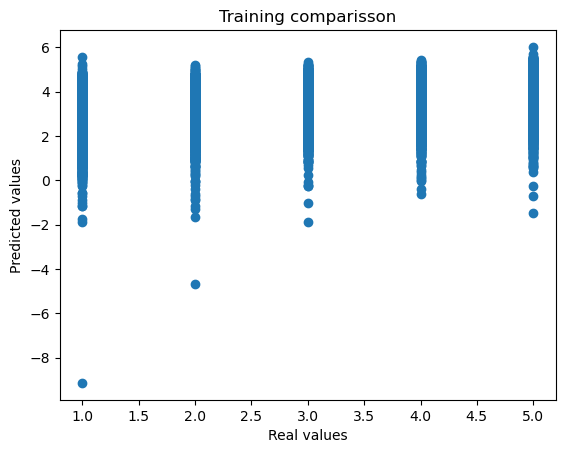

In [ ]:
# Plot training
plt.scatter(train_y, train_y_pred)
plt.xlabel('Real values')
plt.ylabel('Predicted values')
plt.title('Training comparisson')

plt.savefig(directory_name + "/Training_comparisson_" + current_datetime + ".png")

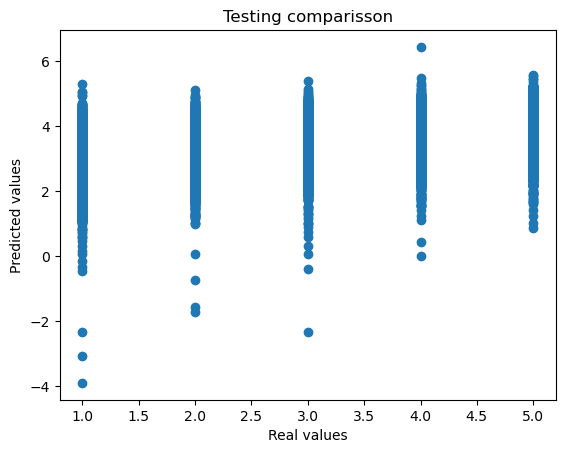

In [ ]:
# Plot testing
plt.scatter(test_y, test_y_pred)
plt.xlabel('Real values')
plt.ylabel('Predicted values')
plt.title('Testing comparisson')

plt.savefig(directory_name + "/Testing_comparisson_" + current_datetime + ".png")

## 6. Export
Now, the pickle file and the model summary will be exported

In [ ]:
def play_system_sound():
    if platform.system() == "Windows":
        import winsound
        winsound.PlaySound("*", winsound.SND_ALIAS)
    elif platform.system() == "Darwin":  # macOS
        os.system("afplay /System/Library/Sounds/Glass.aiff")

In [ ]:
def check_list_elements(variable):
    # Check if the variable is a list
    if isinstance(variable, list):
        # Check if all elements in the list are not strings and the list has at least 2 elements
        if all(not isinstance(item, str) for item in variable) and len(variable) >= 2:
            return True
    return False

In [ ]:
def transform_list_of_dicts_to_dict_of_lists(input_list):
    output_dict = {}

    # Iterate over each dictionary in the input list
    for d in input_list:
        # Iterate over each key in the dictionary
        for key, value in d.items():
            # If the key is not in the output dictionary, add it with an empty list
            if key not in output_dict:
                output_dict[key] = []
            # Append the value to the list associated with the key in the output dictionary
            output_dict[key].append(value)

    return output_dict

In [ ]:
def create_excel_file(file_name, dataframes_dict):
    # Create a Pandas Excel writer using the file_name
    with pd.ExcelWriter(f"{file_name}.xlsx", engine='xlsxwriter') as writer:
        # Iterate over each key-value pair in the dictionary
        for sheet_name, df in dataframes_dict.items():
            # Write each DataFrame to a separate worksheet without the index
            df.to_excel(writer, sheet_name=sheet_name, index=False)

### 6.1. General

In [ ]:
## Get extreme hyperparameters

# Get best_hyperparameters
best_hyperparams = random_search.best_params_

# Get list of parameters to check
params_grid_tocheck = [hyperparam for hyperparam, value in params_grid.items() if check_list_elements(value)]

# Initialize list of hyperparams which are extreme
extreme_hyperparams = []

# Iterate through hyperparams to check
for hyperparam in params_grid_tocheck:

    # Check if hyperparam is in both dictionaries as keys
    if not (hyperparam in params_grid):
        continue

    # Get max and min values
    max_val = max(params_grid[hyperparam])
    min_val = min(params_grid[hyperparam])

    # Check if the best one is in an extreme
    if (best_hyperparams == max_val) or (best_hyperparams == min_val):

        # Get if max or min
        which_extreme = "max" if best_hyperparams == max_val else "min"

        # Add to list
        extreme_hyperparams.append(hyperparam + ": " + which_extreme)

# Concatenate list
extreme_hyperparams_str = "; ".join(extreme_hyperparams)

# Add to str_out
str_out = str_out + extreme_hyperparams_str

In [ ]:
# Append model summary
with open("05_outputs_modeling/model_summary.txt", "a") as file:
    file.write("\n" + str_out)

In [ ]:
# Create pickle object
pickle_file_path = directory_name + "/dict_" + current_datetime + ".pkl"

with open(pickle_file_path, 'wb') as pickle_file:
    pickle.dump(dict_out, pickle_file)

In [ ]:
# Create json file
json_file_path = directory_name + "/config_" + current_datetime + ".json"

with open(json_file_path, 'w') as json_file:
    json.dump(config, json_file)

### 6.3. Dashboard

In [ ]:
# Initialize complete output dictionary
dict_out_complete = {}

In [ ]:
# Prepare general output
dict_out_general = {
    'Execution name': [current_datetime],
    'Model type': [config['model']['model type']],
    'PCA':["No" if config['pca']['number of pca']==0 else "Yes"],
    'Number of search iterations': [config['search']['number search iterations']],
    'Number of folds': [config['search']['number folds']],
    'Train time': [str(endtime - starttime)],
    'Metric 1': ["MAPE"],
    'Metric 1 train': [metric_mape_train],
    'Metric 1 test': [metric_mape_test],
    'Metric 2': ["MSE"],
    'Metric 2 train': [metric_mse_train],
    'Metric 2 test': [metric_mse_test]

}

# Save general output
dict_out_complete['General'] = pd.DataFrame(dict_out_general)

In [ ]:
# Save predictions
dict_out_complete['Train predictions'] = pd.merge(train_real, train_pred, on='review_id', how='outer').rename(columns={'overall_rating': 'Real_' + current_datetime, '0': 'Predicted_' + current_datetime})
dict_out_complete['Test predictions'] = pd.merge(test_real, test_pred, on='review_id', how='outer').rename(columns={'overall_rating': 'Real_' + current_datetime, '0': 'Predicted_' + current_datetime})

In [ ]:
# Save cross-validation deepdive
cols = ['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'mean_test_score', 'std_test_score', 'rank_test_score'] + ['split' + str(split) + '_test_score' for split in range(config['search']['number folds'])]
dict_out_complete['Execution deepdive'] = pd.DataFrame({col: dict_out['Random search object'].cv_results_[col] for col in cols})
dict_out_complete['Execution deepdive']['Execution name'] = current_datetime

lst_parameters = list(random_search.cv_results_['params'][0].keys())

hyperparam_dataframe = pd.DataFrame(transform_list_of_dicts_to_dict_of_lists(dict_out['Random search object'].cv_results_['params']))

param_num = -1
for hyperparam in lst_parameters:

    # Add one param number
    param_num +=1

    # Get values of hyperparams
    hyperparam_dataframe["param_" + str(param_num)] = hyperparam_dataframe[hyperparam].copy()

    # Get column name
    hyperparam_dataframe["param_" + str(param_num) + "_name"] = hyperparam

# Add to complete dataframe
cols_to_add_1 = ["param_" + str(num) for num in range(param_num+1)]
cols_to_add_2 = ["param_" + str(num) + "_name" for num in range(param_num+1)]
cols_to_add = [item for pair in zip(cols_to_add_2, cols_to_add_1) for item in pair]
dict_out_complete['Execution deepdive'] = dict_out_complete['Execution deepdive'].join(hyperparam_dataframe[cols_to_add])

In [ ]:
%pip install pandas numpy scikit-learn xgboost matplotlib openpyxl xlsxwriter
create_excel_file(directory_name + "/Dashboard output_" + current_datetime + ".xlsx", dict_out_complete)

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Print
print("Everything worked!")

Everything worked!


In [ ]:
# Play sound that is finished
play_system_sound()
play_system_sound()
play_system_sound()
play_system_sound()
play_system_sound()
play_system_sound()
play_system_sound()
play_system_sound()
play_system_sound()
play_system_sound()